# Setup

In [1]:
# INSTALLATION

#!pip install cellpose==3.1.1 -q
#print("Installed")

In [ ]:
# #restart kernel after
# !pip install "numpy<2.0" pandas --upgrade

In [3]:
!pip install cellpose -q
print("Installed")
!pip install cellpose --upgrade
!pip install git+https://github.com/facebookresearch/dinov3

Installed
  Cloning https://github.com/facebookresearch/dinov3 to /tmp/pip-req-build-c8bnxe8_
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/dinov3 /tmp/pip-req-build-c8bnxe8_
  Resolved https://github.com/facebookresearch/dinov3 to commit 6876159a11b4df116f30f667f8c9888617df0751
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
# IMPORTS

#from google.colab import drive
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as Image
from cellpose import models, utils
from skimage import io, color, exposure, filters, measure, morphology
import plotly.express as px
from skimage.segmentation import find_boundaries
from scipy import ndimage

# Global text size for all plots
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Pictures loading and preprocessing

In [10]:
# PICTURE LOADING

image_path = "/kaggle/input/datasets/vickigruslin/culturre2-ctrl/260310_DIV1_Slip1_20x.jpg"
if os.path.exists(image_path):
    print("Picture found!")
    image = Image.open(image_path).convert('L')         
    img_array = np.array(image)                         # 8-bit grayscale
    print(f"Dimensions : {img_array.shape}")
    image_rgb = Image.open(image_path).convert('RGB')
    img_array_rgb = np.array(image_rgb)                 # original image 
else:
    print(f"Error : Picture not foung in {image_path}")
    print("Data available  :", os.listdir("/kaggle/input/datasets/vickigruslin"))

output_dir = "/kaggle/working/results/Control"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Picture found!
Dimensions : (2160, 3840)


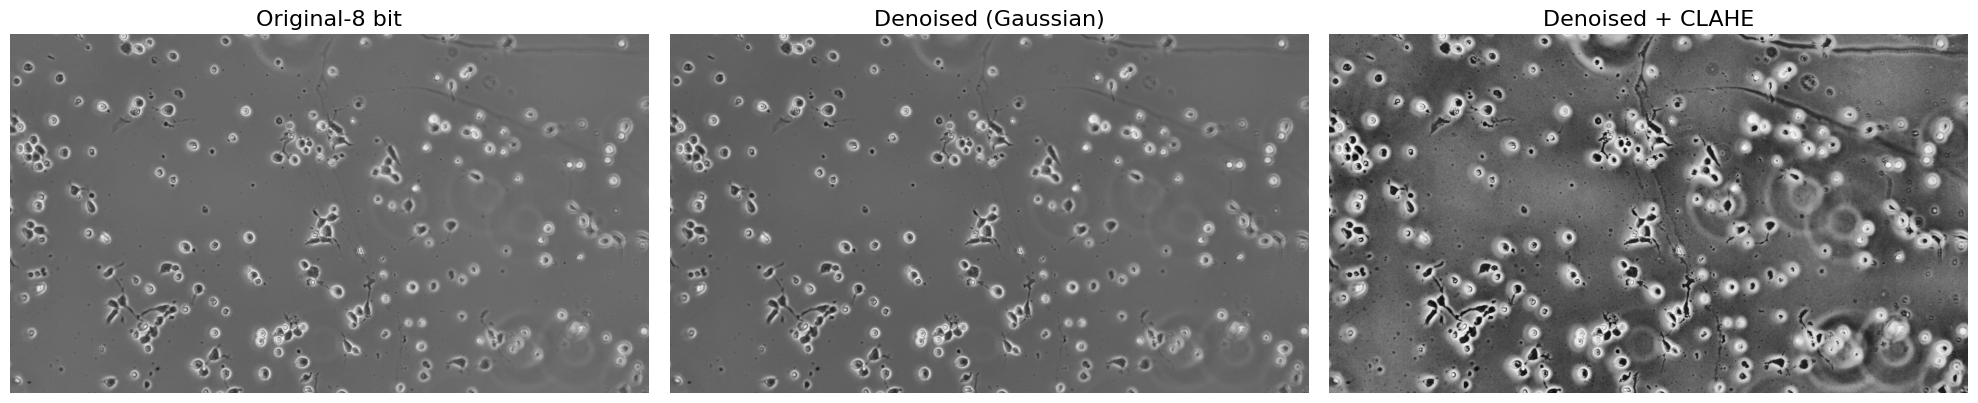

In [ ]:
# PREPROCESSING

# 1 — Noise reduction
img_denoised = filters.gaussian(img_array, sigma=1)
img_denoised = (img_denoised * 255).astype(np.uint8)

# 2 — CLAHE (Contrast normalization)
img_preprocessed = exposure.equalize_adapthist(img_denoised, clip_limit=0.03)   #clip_limit => contrast enhancement intensity
img_preprocessed = (img_preprocessed * 255).astype(np.uint8)    #values between 0.0 and 1.0 (float) instead of 0 to 255 (uint8)

# Visualization 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original-8 bit")
axes[0].axis('off')
axes[1].imshow(img_denoised, cmap='gray')
axes[1].set_title("Denoised (Gaussian)")
axes[1].axis('off')
axes[2].imshow(img_preprocessed, cmap='gray')
axes[2].set_title("Denoised + CLAHE")
axes[2].axis('off')
plt.tight_layout()
plt.savefig("preprocessing_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# FUNCTION FOR MASK PLOTS

def plot_masks(image, masks, title, alpha=0.6, cmap_name='cool'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(image, cmap='gray')
    mask_uni = (masks > 0).astype(float)
    mask_display = np.ma.masked_where(mask_uni == 0, mask_uni)
    axes[1].imshow(mask_display, cmap=cmap_name, alpha=alpha, interpolation='none')
    axes[1].set_title(title)
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('mask_segmentation.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_borders_masks(image, masks, title, alpha=1., cmap_name='cool'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(image, cmap='gray')
    mask_uni = (masks > 0).astype(float)
    boundaries = find_boundaries(mask_uni > 0, mode='thick')
    thick_boundaries = ndimage.binary_dilation(boundaries, iterations=2)
    mask_display = np.ma.masked_where(thick_boundaries == 0, thick_boundaries)
    axes[1].imshow(mask_display, cmap=cmap_name, alpha=alpha, interpolation='none')
    axes[1].set_title(title)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()              

# Segmentation

In [ ]:
# SEGMENTATION
model = models.CellposeModel(gpu=True, pretrained_model='cpdino')
masks, flows, styles = model.eval(
    img_denoised,
    #channels = [0,0],
    channels = None,             # version 4 detects auto the grayscale
    flow_threshold = 0.6,        # increase if not enough detected / to force separation
    diameter= 45,
    cellprob_threshold= -2,      # decrease to accept more cells
    min_size= 1000,              # default = 15
    augment=True,
    resample=True,               # boundaries more precise
)

diams = utils.diameters(masks)[0]
print(f" {masks.max()} somas detected")
print(f"Mean diameter  estimated : {diams:.1f} px")

100%|██████████| 1.13G/1.13G [00:11<00:00, 104MB/s]    


 238 somas detected
Mean diameter  estimated : 64.4 px


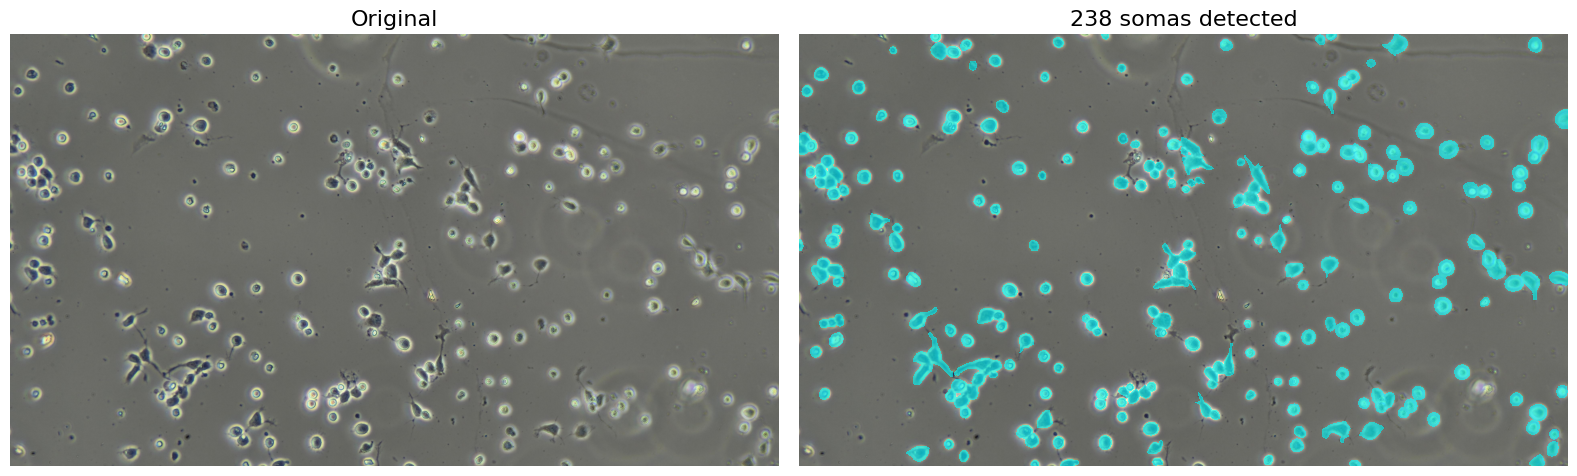

In [14]:
plot_masks(img_array_rgb, masks, f"{masks.max()} somas detected")

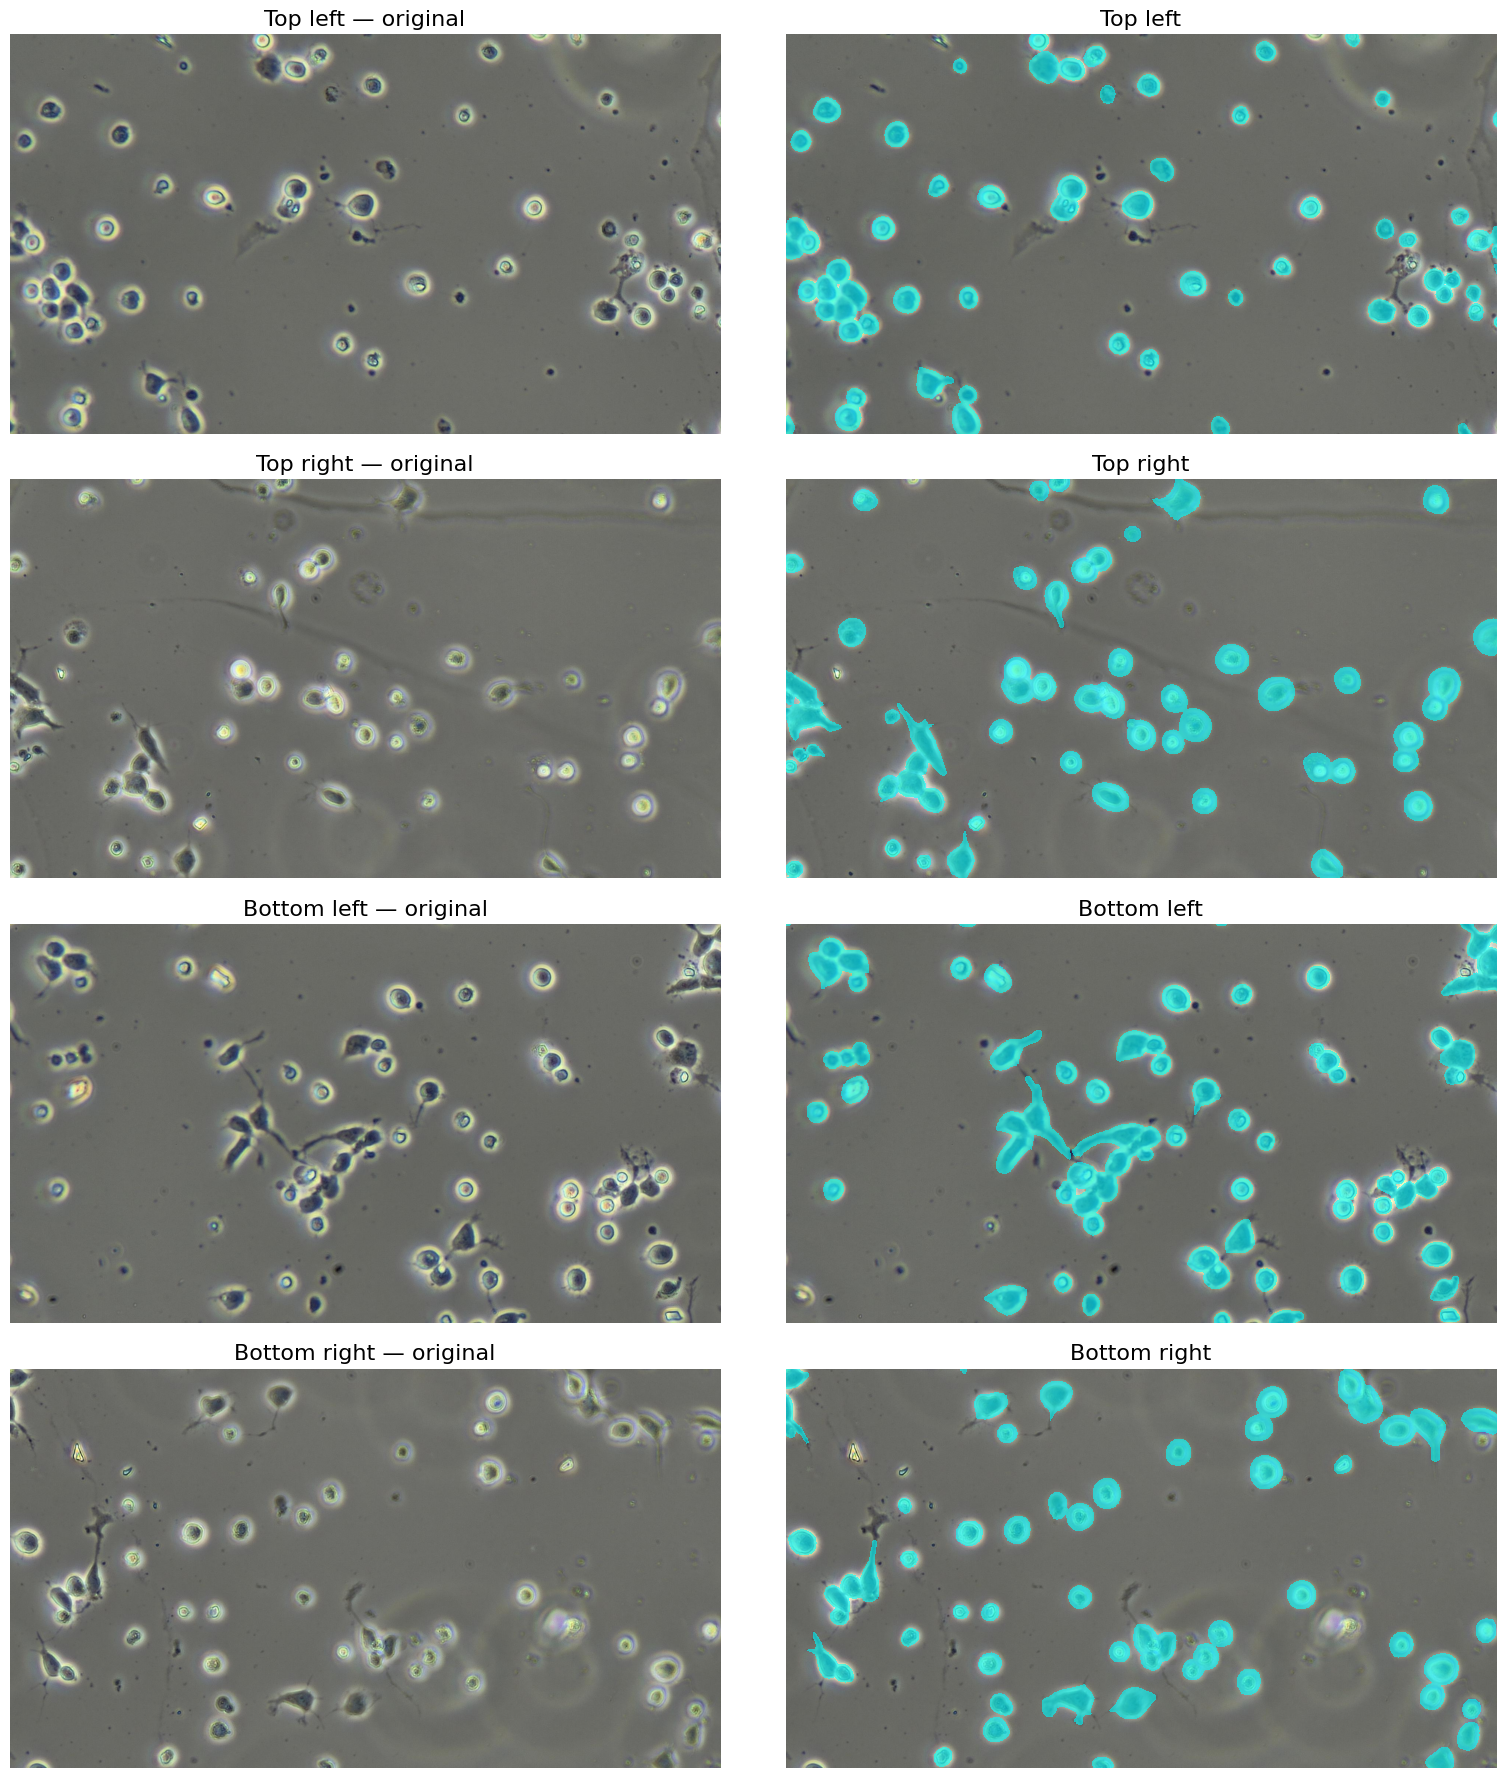

In [15]:
# SEGMENTATION VERIFICATION (ZOOM PLOT)

h, w = img_array.shape[0], img_array.shape[1]
mi_h, mi_w = h // 2, w // 2

quadrants = {
    "Top left": (0, 0, mi_w, mi_h),
    "Top right": (mi_w, 0, w, mi_h),
    "Bottom left": (0, mi_h, mi_w, h),
    "Bottom right": (mi_w, mi_h, w, h),
}

fig, axes = plt.subplots(4, 2, figsize=(16, int(16 * (mi_h/mi_w) * 4 / 2)))

for i, (name, (x1, y1, x2, y2)) in enumerate(quadrants.items()):
    img_zone = img_array_rgb[y1:y2, x1:x2]
    masks_zone = masks[y1:y2, x1:x2]
    n_zone = len(np.unique(masks_zone)) - 1

    axes[i][0].imshow(img_zone, cmap='gray')
    axes[i][0].set_title(f"{name} — original")
    axes[i][0].axis('off')
    axes[i][1].imshow(img_zone, cmap='gray')
    mask_uni = (masks_zone > 0).astype(float)
    mask_display = np.ma.masked_where(mask_uni == 0, mask_uni)
    axes[i, 1].imshow(mask_display, cmap='cool', alpha=0.6, interpolation='none')
    axes[i][1].set_title(f"{name}")
    axes[i][1].axis('off')

plt.tight_layout()
plt.savefig('quadrant_check.png', dpi=300, bbox_inches='tight')
plt.show()

# Somas/Glials filter

In [16]:
# FUNCTION FOR DETECTED SOMAS CLASSIFICATION

from skimage.measure import regionprops, label
from skimage.segmentation import mark_boundaries
from skimage.color import label2rgb
import matplotlib.patches as mpatches
from scipy import ndimage
from matplotlib.colors import ListedColormap

def classify_somas(masks_cellpose, raw_image, image_plot, intensity_threshold):
    
    masks_somas = np.copy(masks_cellpose)
    masks_glials = np.zeros_like(masks_cellpose)
    props = regionprops(masks_cellpose, intensity_image=raw_image)
    glials_count = 0
    
    for prop in props:
        
        label_id = prop.label

        equivalent_radius = np.sqrt(prop.area / np.pi)
        erosion_iterations = int(round(equivalent_radius * 0.5))
        erosion_iterations = max(1, erosion_iterations)
        object_mask = prop.image
        object_intensity = prop.intensity_image
        eroded_mask = ndimage.binary_erosion(object_mask, iterations=erosion_iterations)

        if np.any(eroded_mask):
            inner_intensity = np.mean(object_intensity[eroded_mask])
        else:
            inner_intensity = np.min(prop.intensity_image[object_mask])
        
        too_bright = inner_intensity > intensity_threshold
        
        if too_bright:
            
            masks_glials[masks_cellpose == label_id] = label_id
            masks_somas[masks_cellpose == label_id] = 0
            glials_count += 1
            
    total_detected = len(props)
    nb_glials = glials_count
    nb_somas = total_detected - nb_glials
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    axes[0].imshow(image_plot)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(image_plot, cmap='gray')
    masks_somas_uni = (masks_somas > 0).astype(float)
    masks_somas_display = np.ma.masked_where(masks_somas_uni == 0, masks_somas_uni)
    masks_glials_uni = (masks_glials > 0).astype(float)
    masks_glials_display = np.ma.masked_where(masks_glials_uni == 0, masks_glials_uni)
    axes[1].imshow(masks_somas_display, cmap = ListedColormap(['#00FF00']), alpha=0.6, interpolation='none')    #green
    axes[1].imshow(masks_glials_display, cmap = ListedColormap(['#FF0000']), alpha=0.6, interpolation='none')     #red
    axes[1].set_title(f"Classification: {nb_somas} somas (Green) | {nb_glials} glials (Red)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('classification.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    return masks_somas, nb_somas, masks_glials, glials_count

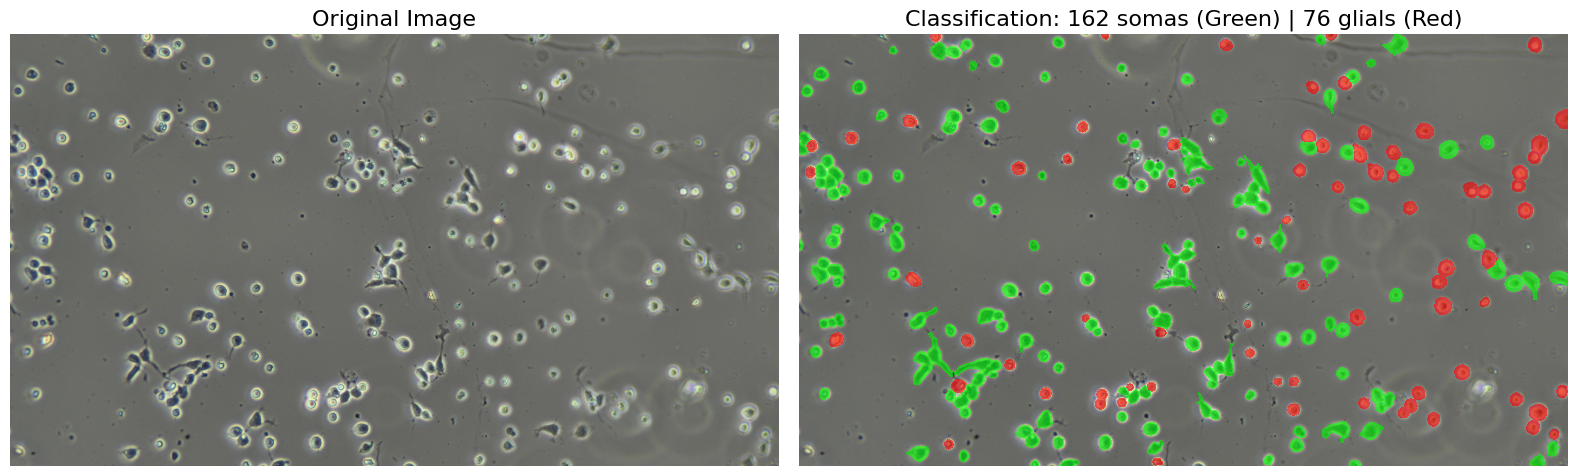

In [17]:
m_somas, n_somas, m_glials, n_glials = classify_somas(masks, img_array, img_array_rgb, 140)

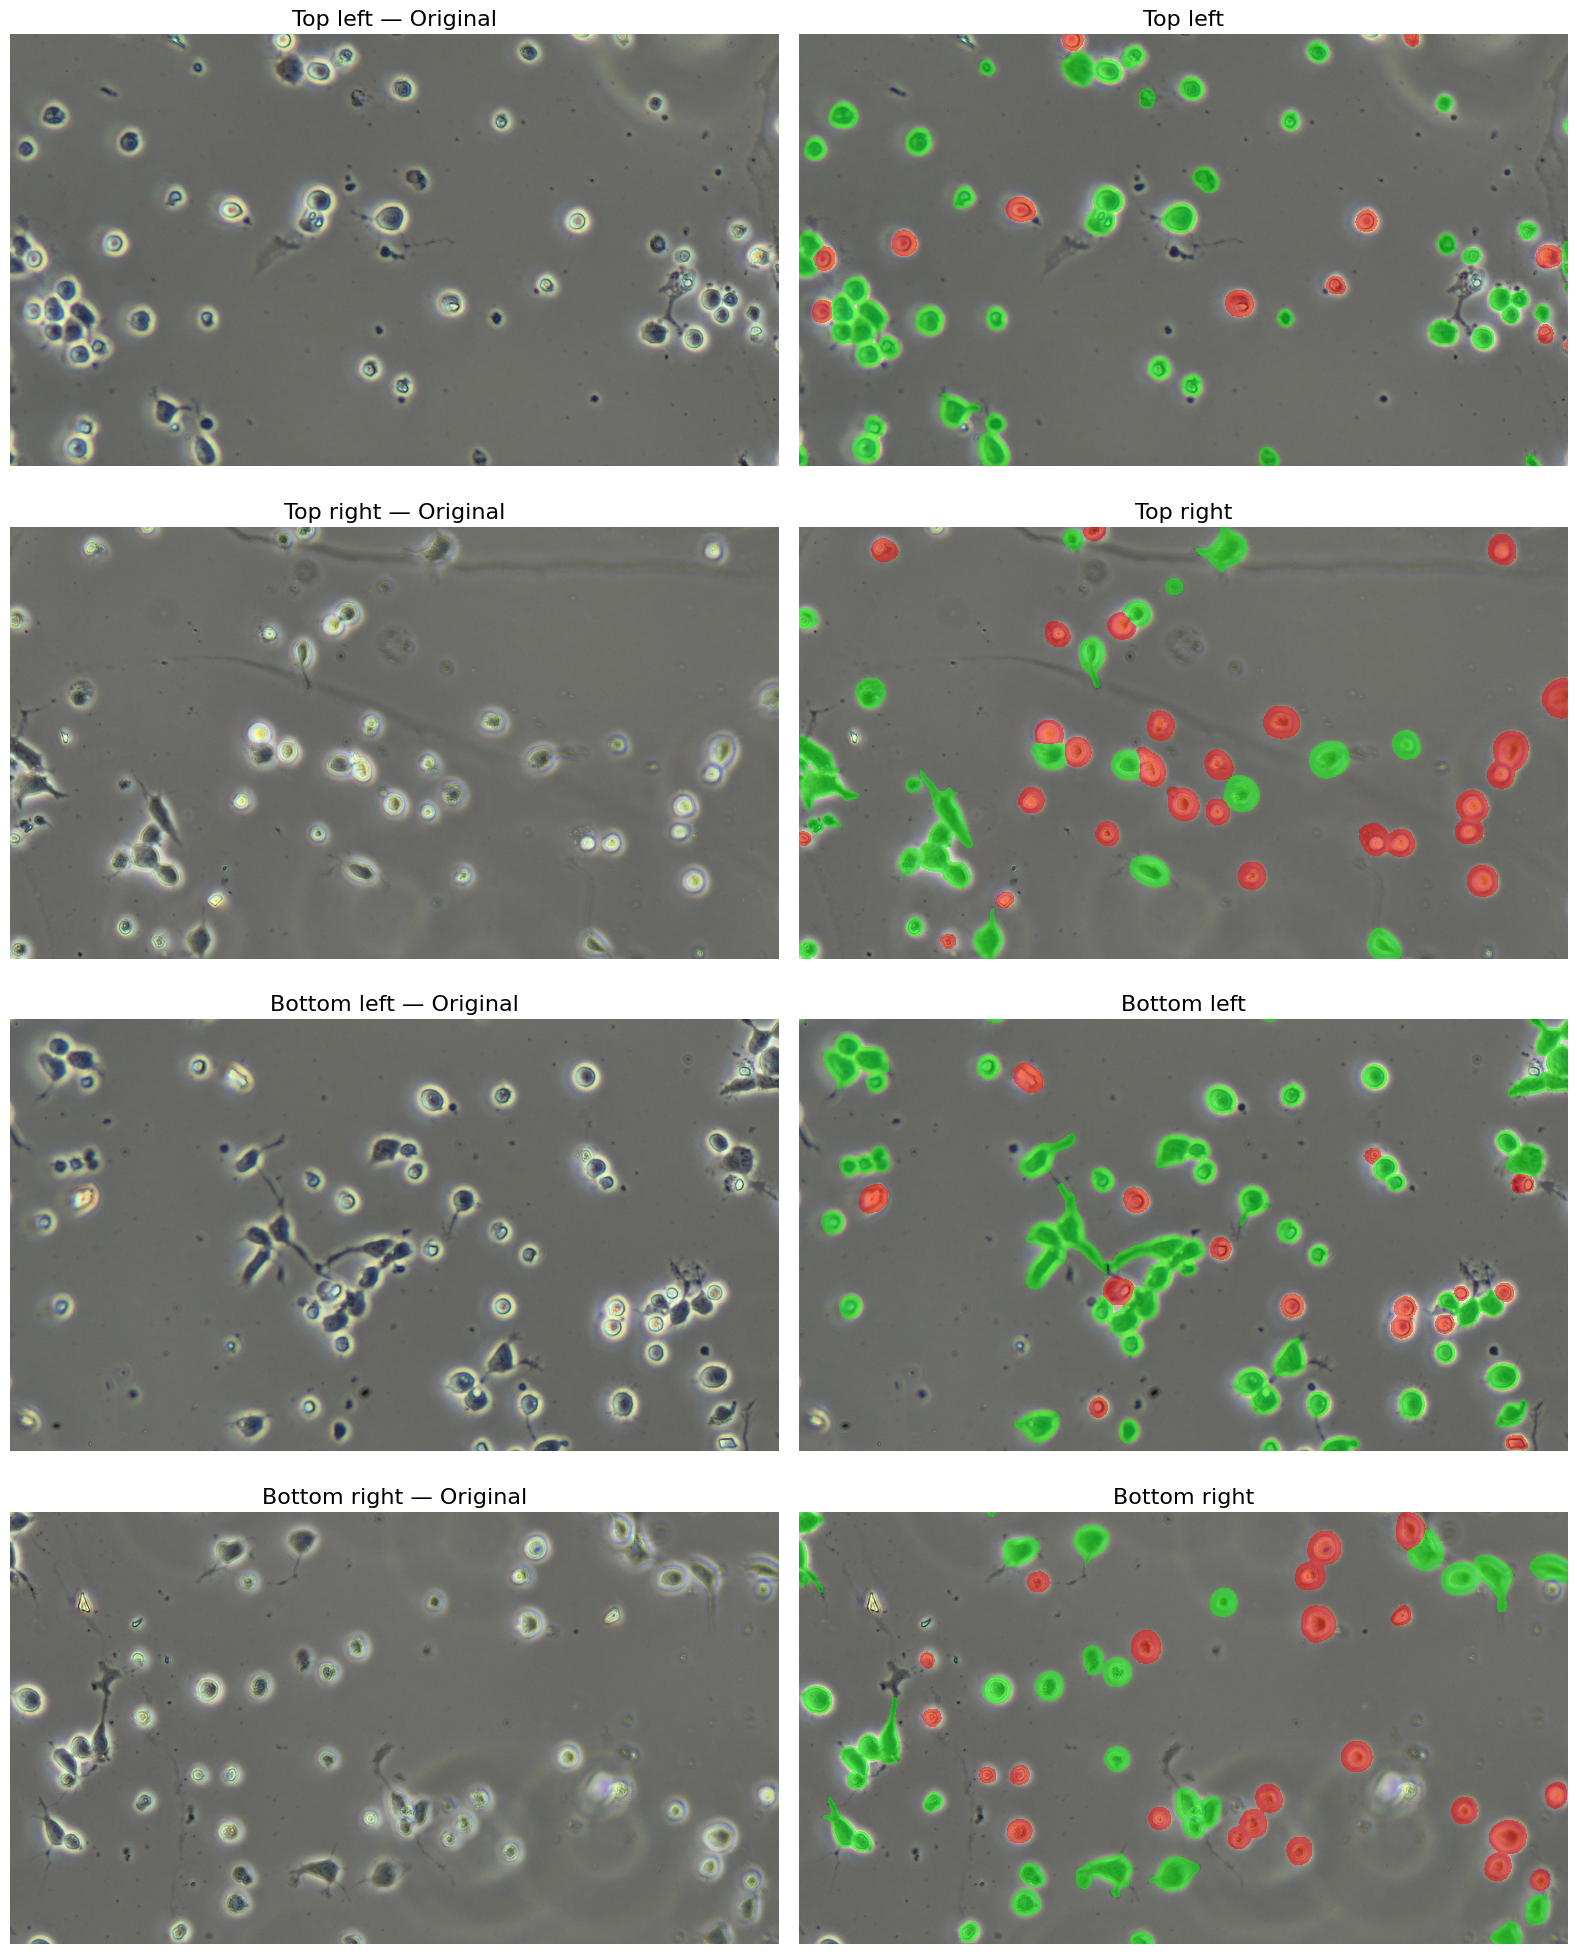

In [ ]:
# ZOOM

h, w = img_array.shape 
mi_h, mi_w = h // 2, w // 2

quadrants = {
    "Top left": (0, 0, mi_w, mi_h),
    "Top right": (mi_w, 0, w, mi_h),
    "Bottom left": (0, mi_h, mi_w, h),
    "Bottom right": (mi_w, mi_h, w, h),
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for i, (name, (x1, y1, x2, y2)) in enumerate(quadrants.items()):
    img_zone = img_array_rgb[y1:y2, x1:x2]
    somas_zone = m_somas[y1:y2, x1:x2] 
    glials_zone = m_glials[y1:y2, x1:x2]  
    n_somas_z = len(np.unique(somas_zone)) - 1
    n_glials_z  = len(np.unique(glials_zone)) - 1

    axes[i][0].imshow(img_zone, cmap='gray')
    axes[i][0].set_title(f"{name} — Original")
    axes[i][0].axis('off')
    axes[i][1].imshow(img_zone, cmap='gray')
    mask_a_display = np.ma.masked_where(somas_zone == 0, somas_zone)
    axes[i, 1].imshow(mask_a_display, cmap = ListedColormap(['#00FF00']), alpha=0.5, interpolation='none')
    mask_d_display = np.ma.masked_where(glials_zone == 0, glials_zone)
    axes[i, 1].imshow(mask_d_display, cmap = ListedColormap(['#FF0000']), alpha=0.5, interpolation='none')
    axes[i][1].set_title(f"{name}")
    axes[i][1].axis('off')
plt.tight_layout()
plt.show()

# Outputs

In [ ]:
# SAVE MASK AND CSV

base_name = os.path.splitext(os.path.basename(image_path))[0] #ex: 260310_DIV1_Slip1_40x
mask_all_filename = f"{base_name}_mask_all.tif"
mask_somas_filename = f"{base_name}_mask_somas.tif"
mask_glials_filename = f"{base_name}_mask_glials.tif"
csv_filename = f"{base_name}_somas_centroids.csv"

Image.fromarray(masks.astype(np.uint16)).save(os.path.join(output_dir, mask_all_filename))
Image.fromarray(m_somas.astype(np.uint16)).save(os.path.join(output_dir, mask_somas_filename))
Image.fromarray(m_glials.astype(np.uint16)).save(os.path.join(output_dir, mask_glials_filename))

rows = [{'label': prop.label,
         'x': round(prop.centroid[1], 1),
         'y': round(prop.centroid[0], 1),
         'mean_intensity': round(prop.mean_intensity, 2),
         'status': "glials" if np.any(m_glials[masks == prop.label] > 0) else "somas"}        
        for prop in measure.regionprops(masks, intensity_image=img_array)]

df_results = pd.DataFrame(rows)
df_results.to_csv(os.path.join(output_dir, csv_filename), index=False)

print(f"Saved : {mask_all_filename} ({len(rows)} somas)")
print(f"Saved : {mask_somas_filename} ({n_somas} somas)")
print(f"Saved : {mask_glials_filename} ({n_glials} somas)")
print(f"Saved : {csv_filename}")

Saved : 260310_DIV1_Slip1_20x_mask_all.tif (238 somas)
Saved : 260310_DIV1_Slip1_20x_mask_somas.tif (162 somas)
Saved : 260310_DIV1_Slip1_20x_mask_glials.tif (76 somas)
Saved : 260310_DIV1_Slip1_20x_somas_centroids.csv


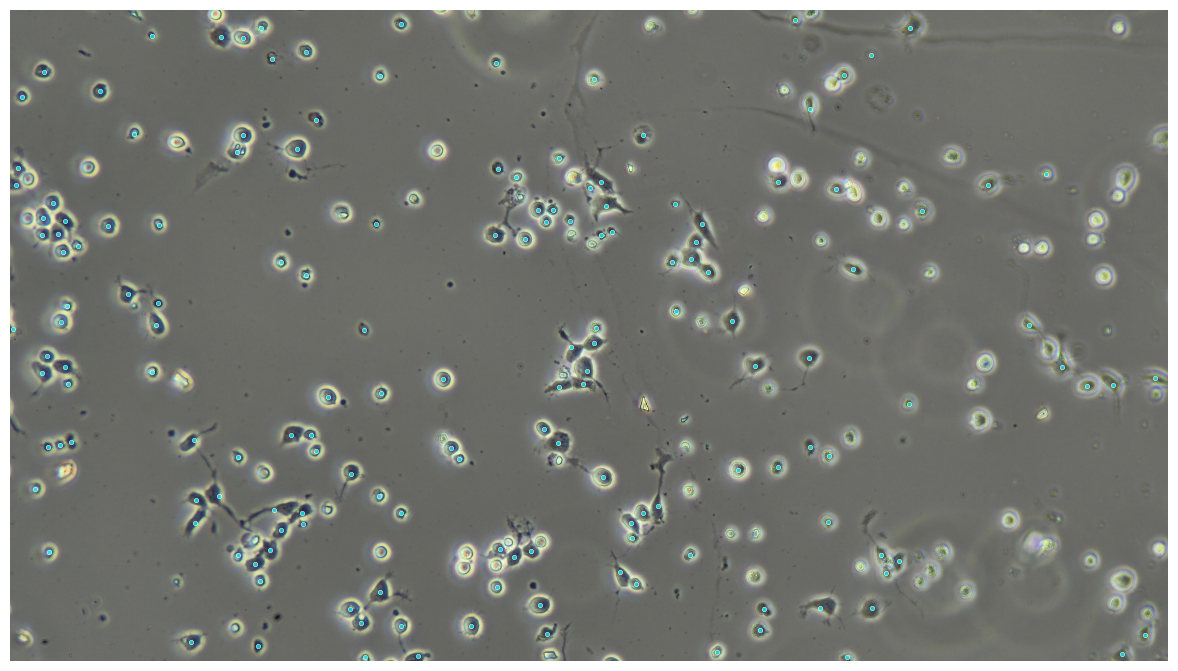

In [20]:
# CENTROIDS VISUALISATION

import cv2

df_somas = df_results[df_results['status'] == "somas"]

plt.figure(figsize=(12, 8))
plt.imshow(img_array_rgb, cmap='gray')
plt.scatter(df_somas['x'], df_somas['y'], s=10, c='cyan', alpha=0.7, edgecolors='white', linewidth=0.5)
plt.axis('off') 
plt.tight_layout()
plt.savefig('centroids.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# EMPTY OUTPUT FOLDER

#!rm -rf /kaggle/working/results/*

# Batch processing

In [ ]:
# BATCH - PARAMETERS & IMAGES LIST

import glob
import shutil
import gc
import time
import torch
from tqdm.auto import tqdm

input_dir = "/kaggle/input/datasets/vickigruslin/culturre2-ctrl"

batch_output_dir = "/kaggle/working/results/culture2-ctrl_20x"
os.makedirs(batch_output_dir, exist_ok=True)

intensity_threshold = 140

image_paths = sorted(glob.glob(os.path.join(input_dir, "*20x*.jpg")))

print(f"{len(image_paths)} pictures 20x found in {input_dir} :")
for p in image_paths:
    print(" -", os.path.basename(p))


In [ ]:
# BATCH - ONE IMAGE PROCESSING FUNCTION
# Follows the pipeline of the preceding cells 
#(loading -> preprocessing -> segmentation -> soma/glial classification -> saving) for one image,
# naming each output file using the image's base name.
# Returns a “resume” dictionary (useful for building a “recap” array at the end of the batch).

def process_image(image_path, output_dir, model, intensity_threshold=140, show_plots=False):

    base_name = os.path.splitext(os.path.basename(image_path))[0]

    # --- Loading ---
    image = Image.open(image_path).convert('L')
    img_array = np.array(image)
    image_rgb = Image.open(image_path).convert('RGB')
    img_array_rgb = np.array(image_rgb)

    # --- Preprocessing  ---
    img_denoised = filters.gaussian(img_array, sigma=1)
    img_denoised = (img_denoised * 255).astype(np.uint8)

    # --- Segmentation  ---
    masks, flows, styles = model.eval(
        img_denoised,
        channels=None,
        flow_threshold=0.6,
        diameter=45,
        cellprob_threshold=-1,
        min_size=1000,
        augment=True,
        resample=True,
    )
    n_total = int(masks.max())

    # --- Visualisation : segmentation masks ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    axes[0].imshow(img_array_rgb, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(img_array_rgb, cmap='gray')
    mask_uni = (masks > 0).astype(float)
    mask_display = np.ma.masked_where(mask_uni == 0, mask_uni)
    axes[1].imshow(mask_display, cmap='cool', alpha=0.6, interpolation='none')
    axes[1].set_title(f"{n_total} somas detected")
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{base_name}_segmentation.png"), dpi=300, bbox_inches='tight')
    if show_plots:
        plt.show()
    plt.close(fig)

    # --- Classification somas / glials ---
    masks_somas = np.copy(masks)
    masks_glials = np.zeros_like(masks)
    props = measure.regionprops(masks, intensity_image=img_array)
    glials_count = 0

    for prop in props:
        label_id = prop.label
        equivalent_radius = np.sqrt(prop.area / np.pi)
        erosion_iterations = max(1, int(round(equivalent_radius * 0.5)))
        object_mask = prop.image
        object_intensity = prop.intensity_image
        eroded_mask = ndimage.binary_erosion(object_mask, iterations=erosion_iterations)

        if np.any(eroded_mask):
            inner_intensity = np.mean(object_intensity[eroded_mask])
        else:
            inner_intensity = np.min(prop.intensity_image[object_mask])

        if inner_intensity > intensity_threshold:
            masks_glials[masks == label_id] = label_id
            masks_somas[masks == label_id] = 0
            glials_count += 1

    n_somas = n_total - glials_count
    n_glials = glials_count

    # --- Visualisation : classification masks ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    axes[0].imshow(img_array_rgb)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    axes[1].imshow(img_array_rgb, cmap='gray')
    somas_uni = (masks_somas > 0).astype(float)
    somas_display = np.ma.masked_where(somas_uni == 0, somas_uni)
    glials_uni = (masks_glials > 0).astype(float)
    glials_display = np.ma.masked_where(glials_uni == 0, glials_uni)
    axes[1].imshow(somas_display, cmap=ListedColormap(['#00FF00']), alpha=0.6, interpolation='none')
    axes[1].imshow(glials_display, cmap=ListedColormap(['#FF0000']), alpha=0.6, interpolation='none')
    axes[1].set_title(f"Classification: {n_somas} somas (Green) | {n_glials} glials (Red)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{base_name}_classification.png"), dpi=300, bbox_inches='tight')
    if show_plots:
        plt.show()
    plt.close(fig)

    # --- Masks saving (tif) ---
    Image.fromarray(masks.astype(np.uint16)).save(os.path.join(output_dir, f"{base_name}_mask_all.tif"))
    Image.fromarray(masks_somas.astype(np.uint16)).save(os.path.join(output_dir, f"{base_name}_mask_somas.tif"))
    Image.fromarray(masks_glials.astype(np.uint16)).save(os.path.join(output_dir, f"{base_name}_mask_glials.tif"))

    # --- CSV of centroids ---
    rows = [{'label': prop.label,
             'x': round(prop.centroid[1], 1),
             'y': round(prop.centroid[0], 1),
             'mean_intensity': round(prop.mean_intensity, 2),
             'status': "glials" if np.any(masks_glials[masks == prop.label] > 0) else "somas"}
            for prop in props]
    df_results = pd.DataFrame(rows)
    df_results.to_csv(os.path.join(output_dir, f"{base_name}_somas_centroids.csv"), index=False)

    # --- Visualisation : centroids ---
    df_somas = df_results[df_results['status'] == "somas"]
    fig = plt.figure(figsize=(12, 8))
    plt.imshow(img_array_rgb, cmap='gray')
    plt.scatter(df_somas['x'], df_somas['y'], s=10, c='cyan', alpha=0.7, edgecolors='white', linewidth=0.5)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{base_name}_centroids.png"), dpi=300, bbox_inches='tight')
    if show_plots:
        plt.show()
    plt.close(fig)

    # --- Memory cleaning (important for batch processing; otherwise, RAM/VRAM usage will increase with each frame) ---
    del masks, masks_somas, masks_glials, img_denoised, flows, styles
    gc.collect()
    torch.cuda.empty_cache()

    return {
        'image': base_name,
        'n_total': n_total,
        'n_somas': n_somas,
        'n_glials': n_glials,
    }

In [ ]:
# BATCH - EXECUTION ON ALL 20x IMAGES

model = models.CellposeModel(gpu=True, pretrained_model='cpdino')

summary_rows = []
failed_images = []

for image_path in tqdm(image_paths, desc="Pictures processing"):
    base_name = os.path.basename(image_path)
    try:
        t0 = time.time()
        result = process_image(image_path, batch_output_dir, model, intensity_threshold=intensity_threshold, show_plots=False)
        result['time_s'] = round(time.time() - t0, 1)
        summary_rows.append(result)
        print(f"OK  {base_name} -> {result['n_somas']} somas / {result['n_glials']} glials ({result['time_s']}s)")
    except Exception as e:
        print(f"FAILED {base_name} : {e}")
        failed_images.append((base_name, str(e)))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(batch_output_dir, "_batch_summary.csv"), index=False)

print(f"\n{len(summary_rows)}/{len(image_paths)} images processed successfully.")
if failed_images:
    print("Pictures failed :")
    for name, err in failed_images:
        print(f"  - {name} : {err}")

summary_df


In [ ]:
# ZIP OF RESULTS FOR DOWNLOADING

zip_path = "/kaggle/working/culture2-ctrl_20x_results"  
shutil.make_archive(zip_path, 'zip', batch_output_dir)

zip_size_mb = os.path.getsize(zip_path + ".zip") / (1024 * 1024)
print(f"Zip created : {zip_path}.zip ({zip_size_mb:.1f} Mo)")
print("-> In the ‘Output’ tab of the Kaggle notebook, this single .zip file must be visible and downloadable directly.")